In [5]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np

In [2]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 50

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    'PlantDir',
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 2153 files belonging to 3 classes.


In [4]:
class_names= dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

(32, 256, 256, 3)
[1 0 1 0 0 1 0 1 1 2 2 1 0 1 1 0 1 1 0 0 1 0 1 2 1 1 1 1 0 0 1 1]


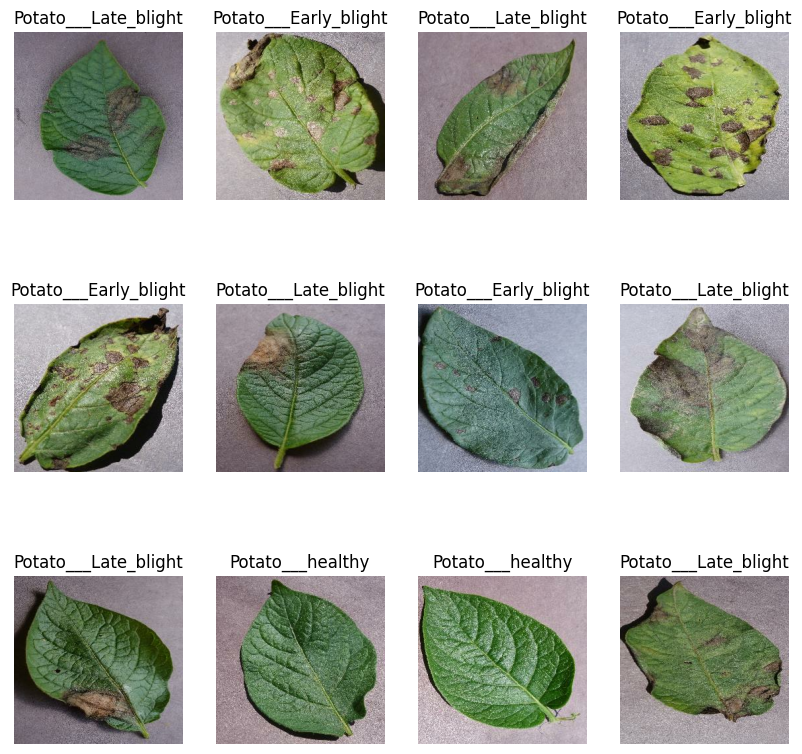

In [5]:
plt.figure(figsize=(10,10))
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())
    for i in range(12):
        a= plt.subplot(3,4,i+1)
        plt.title(class_names[labels_batch[i]])
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.axis("off")

In [6]:
80%=> train
20%=> test
   10%=> Val
   10%=> test 


SyntaxError: invalid syntax (364867551.py, line 1)

In [7]:
train_size = 0.8
len(dataset)*train_size

54.400000000000006

In [8]:
train_ds = dataset.take(54)
len(train_ds)

54

In [9]:
test_ds1 = dataset.skip(54)
len(test_ds1)

14

In [10]:
val_size=0.1
len(dataset)*val_size

6.800000000000001

In [11]:
val_ds= dataset.take(6)
len(val_ds)

6

In [12]:
test_ds= test_ds1.skip(6)
len(test_ds)

8

In [14]:
def get_dataset_partition(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True,shuffle_size=10000):
    assert(train_split+val_split+test_split) == 1
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=13)
        
    train_size = int(train_split*ds_size)  
    val_size   = int(val_split*ds_size)

    train_ds = ds.take(train_size)
    val_ds   = ds.skip(train_size).take(val_size)
    test_ds  = ds.skip(train_size).skip(val_size)

    
    return train_ds, val_ds, test_ds

In [15]:
train_ds, val_ds, test_ds = get_dataset_partition(dataset)

In [16]:
len(train_ds)

54

In [17]:
len(val_ds)

6

In [18]:
len(test_ds)

8

In [19]:
train_ds =  train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds =  val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds =  test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [25]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch[0].numpy()/255)


[[[0.70980394 0.69803923 0.73333335]
  [0.34509805 0.33333334 0.36862746]
  [0.43529412 0.42352942 0.46666667]
  ...
  [0.5529412  0.54509807 0.6       ]
  [0.58431375 0.5764706  0.6313726 ]
  [0.61960787 0.6117647  0.6666667 ]]

 [[0.6156863  0.6039216  0.6392157 ]
  [0.7411765  0.7294118  0.7647059 ]
  [0.4509804  0.4392157  0.48235294]
  ...
  [0.6117647  0.6039216  0.65882355]
  [0.59607846 0.5882353  0.6431373 ]
  [0.58431375 0.5764706  0.6313726 ]]

 [[0.5686275  0.5568628  0.5921569 ]
  [0.41568628 0.40392157 0.4392157 ]
  [0.54509807 0.53333336 0.5764706 ]
  ...
  [0.61960787 0.6117647  0.6666667 ]
  [0.60784316 0.6        0.654902  ]
  [0.5921569  0.58431375 0.6392157 ]]

 ...

 [[0.45490196 0.4392157  0.49411765]
  [0.58431375 0.5686275  0.62352943]
  [0.45882353 0.44313726 0.49803922]
  ...
  [0.75686276 0.7490196  0.7921569 ]
  [0.7490196  0.7411765  0.78431374]
  [0.76862746 0.7607843  0.8039216 ]]

 [[0.6627451  0.64705884 0.7019608 ]
  [0.5176471  0.5019608  0.5568628 ]


In [20]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255)
])

In [21]:
data_augmentation = tf.keras.Sequential([
     layers.RandomFlip(mode="HORIZONTAL_AND_VERTICAL"),
     layers.RandomRotation(0.2)
])

In [22]:
BATCH_SIZE

32

In [23]:
input_shape = (BATCH_SIZE,IMAGE_SIZE, IMAGE_SIZE,CHANNELS)
n_classes = 3

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPool2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])

model.build(input_shape=input_shape)

C:\Users\SAYYED SAUD\Desktop\Blueprints\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [71]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (32, 254, 254, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (32, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (32, 125, 125, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (32, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (32, 60, 60, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (32, 28, 28, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (32, 14, 14, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (32, 12, 12, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (32, 6, 6, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (32, 2304)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (32, 64)                    │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (32, 3)                     │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 277,891 (1.06 MB)

 Trainable params: 277,891 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [25]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS
) 

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 45s 757ms/step - accuracy: 0.5771 - loss: 0.8240 - val_accuracy: 0.7812 - val_loss: 0.6331
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 785ms/step - accuracy: 0.8106 - loss: 0.5171 - val_accuracy: 0.8333 - val_loss: 0.4245
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 765ms/step - accuracy: 0.8604 - loss: 0.3851 - val_accuracy: 0.8646 - val_loss: 0.3223
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 784ms/step - accuracy: 0.8933 - loss: 0.2760 - val_accuracy: 0.9375 - val_loss: 0.1951
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 763ms/step - accuracy: 0.9003 - loss: 0.2541 - val_accuracy: 0.8958 - val_loss: 0.2244
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 780ms/step - accuracy: 0.9255 - loss: 0.1972 - val_accuracy: 0.9323 - val_loss: 0.1716
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 771ms/step - accuracy: 0.9243 - loss: 0.1940 - val_accuracy: 0.9323 - val_loss: 0.1699
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 50s 924ms/step - accuracy: 0.9390 - loss: 0.1663 - val_accu

In [26]:
scores=model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 300ms/step - accuracy: 0.9871 - loss: 0.0208


In [27]:
scores

[0.02081991173326969, 0.9871244430541992]

In [28]:
history.params

{'verbose': 1, 'epochs': 50, 'steps': 54}

In [29]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [30]:
history.history['loss']

[0.8240044116973877,
 0.5171386003494263,
 0.38512229919433594,
 0.276007741689682,
 0.2541424334049225,
 0.19723092019557953,
 0.19404944777488708,
 0.16628527641296387,
 0.21329262852668762,
 0.16088786721229553,
 0.14447709918022156,
 0.11876314878463745,
 0.11715768277645111,
 0.11816945672035217,
 0.1212293952703476,
 0.13056889176368713,
 0.11571846157312393,
 0.08648206293582916,
 0.09166460484266281,
 0.12705431878566742,
 0.08566813915967941,
 0.07182062417268753,
 0.07877930998802185,
 0.07947690039873123,
 0.0540231429040432,
 0.062142156064510345,
 0.06436563283205032,
 0.0504683293402195,
 0.06151007488369942,
 0.08307186514139175,
 0.059440020471811295,
 0.05453680083155632,
 0.03246408700942993,
 0.04255043715238571,
 0.04225343093276024,
 0.018998030573129654,
 0.05620068311691284,
 0.024035921320319176,
 0.04551439359784126,
 0.041911106556653976,
 0.025230905041098595,
 0.014069385826587677,
 0.03104877471923828,
 0.057917989790439606,
 0.03133830428123474,
 0.0510306

In [31]:
history.history['accuracy']

[0.5771260857582092,
 0.8105571866035461,
 0.8604105710983276,
 0.8932551145553589,
 0.900293231010437,
 0.9255132079124451,
 0.9243401885032654,
 0.9390029311180115,
 0.9196481108665466,
 0.9401759505271912,
 0.951906144618988,
 0.9583577513694763,
 0.9589442610740662,
 0.9536656737327576,
 0.9554252028465271,
 0.9548386931419373,
 0.9607037901878357,
 0.9683284163475037,
 0.967155396938324,
 0.9542521834373474,
 0.9712610244750977,
 0.9759531021118164,
 0.9712610244750977,
 0.9665688872337341,
 0.9806451797485352,
 0.9759531021118164,
 0.9765396118164062,
 0.9847507476806641,
 0.9724340438842773,
 0.9689149856567383,
 0.9771261215209961,
 0.9782991409301758,
 0.9876832962036133,
 0.9847507476806641,
 0.9847507476806641,
 0.9929618835449219,
 0.9818181991577148,
 0.9917888641357422,
 0.9818181991577148,
 0.9865102767944336,
 0.9900293350219727,
 0.9958944320678711,
 0.988856315612793,
 0.9759531021118164,
 0.9865102767944336,
 0.9806451797485352,
 0.9859237670898438,
 0.99354839324951

In [32]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']

loss=history.history['loss']
val_loss=history.history['val_loss']



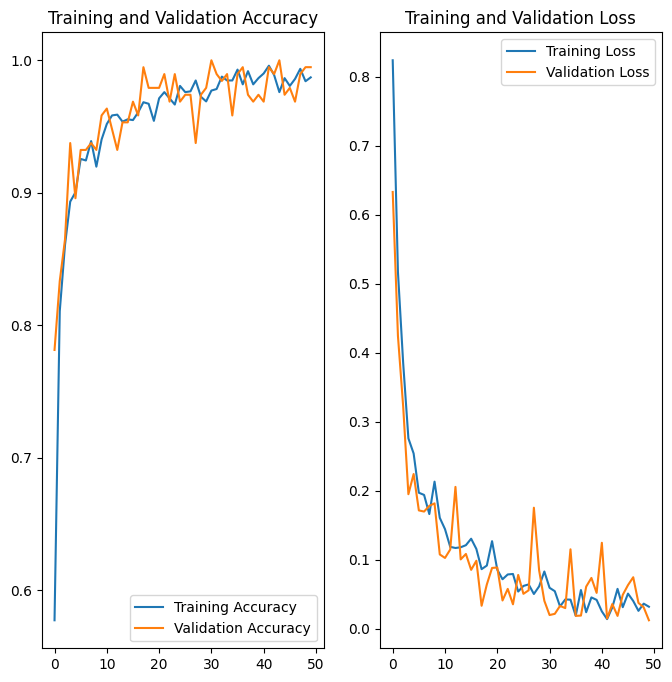

In [33]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()



First image to predict
label: Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Potato___Late_blight


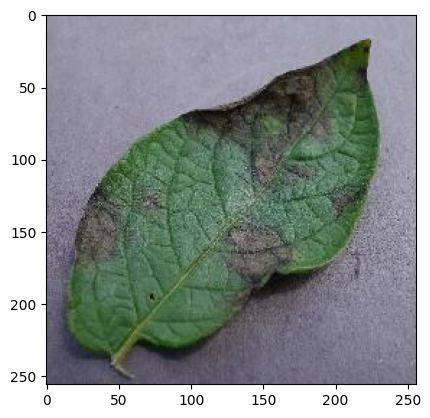

In [69]:
for image_batch, label_batch in test_ds.take(1):
    f_i=image_batch[0].numpy().astype("uint8")
    print("First image to predict")
    plt.imshow(f_i)
    print("label:",class_names[labels_batch[0].numpy()])
    batch_prediction = model.predict(image_batch)
    print(class_names[np.argmax(batch_prediction[0])])

In [75]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array,0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


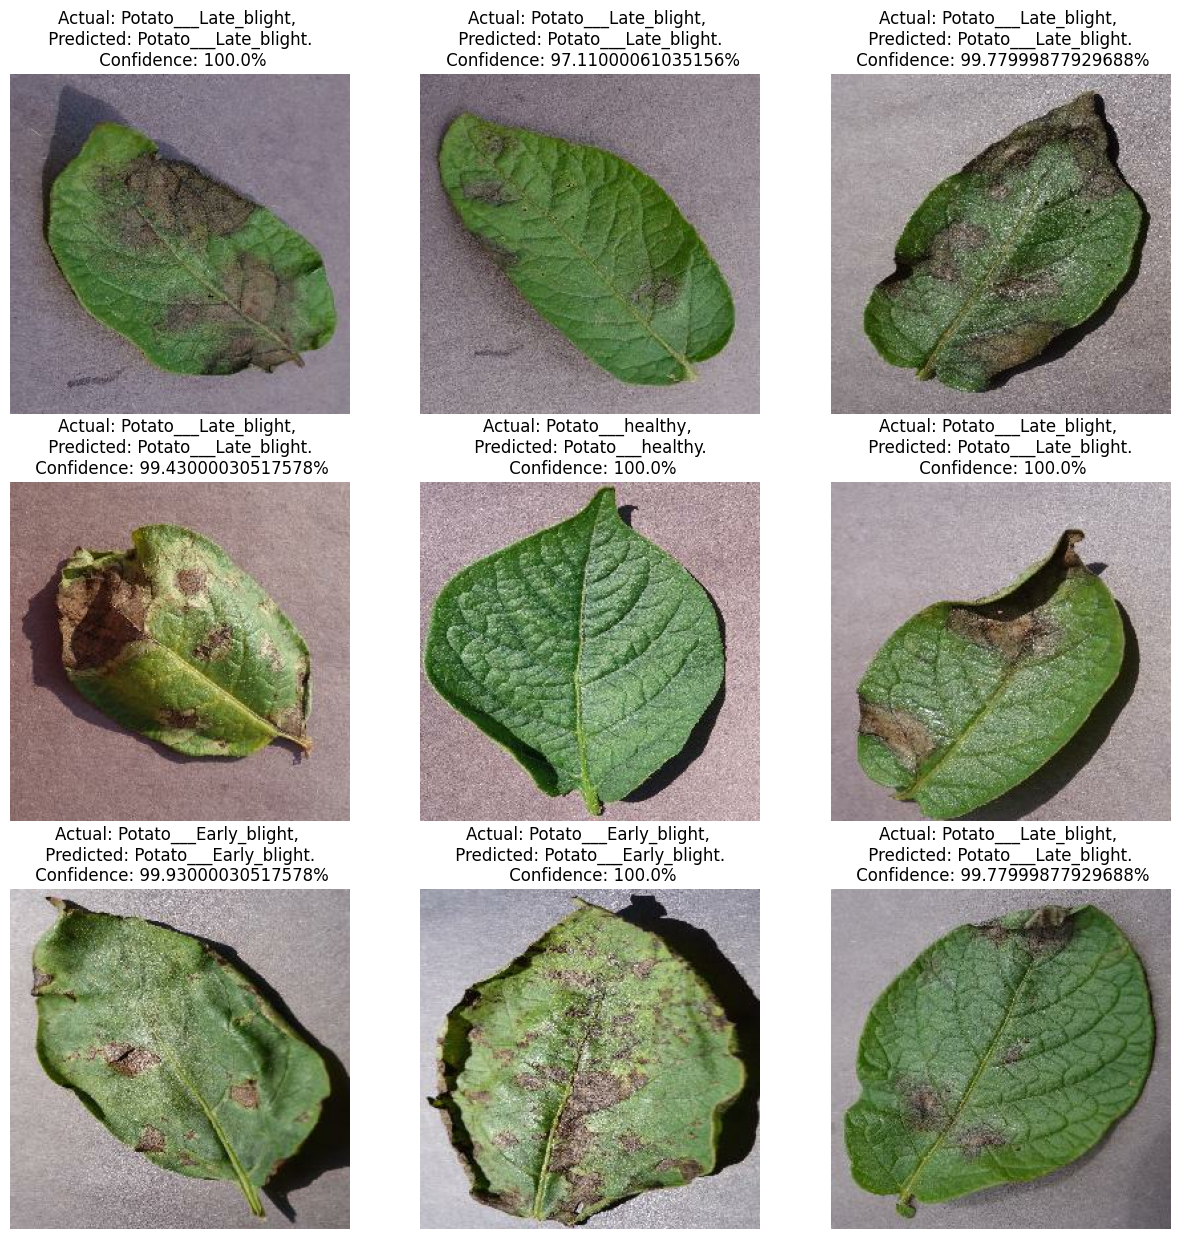

In [79]:
plt.figure(figsize=(15,15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        predicted_class, confidence = predict(model, images[i].numpy())
        
        actual_class  = class_names[labels[i]]
        plt.title(f"Actual: {actual_class}, \n Predicted: {predicted_class}. \n Confidence: {confidence}%" )
        plt.axis('off')

In [6]:
import os

files = os.listdir('../models')

model_version = max(
    [int(f.split('.')[0]) for f in files if f.endswith('.keras')] + [0]
) + 1

model.save(f"./models/{model_version}.keras")

NameError: name 'model' is not defined

In [18]:
model.export("./models/{model_version}")

INFO:tensorflow:Assets written to: ./models/{model_version}\assets


INFO:tensorflow:Assets written to: ./models/{model_version}\assets


Saved artifact at './models/{model_version}'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1726517691664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726517698176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726517896720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726517890208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726517705744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726517902000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726517900768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726518126800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726518131904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726518123456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726518131728: TensorSpec(s

In [19]:
import tensorflow as tf

In [4]:
import os

os.listdir("../models")

['1', '2', '3']

In [23]:
model.export("..models/1")

INFO:tensorflow:Assets written to: ..models/1\assets


INFO:tensorflow:Assets written to: ..models/1\assets


Saved artifact at '..models/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1726517691664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726517698176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726517896720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726517890208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726517705744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726517902000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726517900768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726518126800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726518131904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726518123456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1726518131728: TensorSpec(shape=(), dtype

In [7]:
import tensorflow as tf

model = tf.keras.models.load_model("../models/3")

model.export("../models/3.keras")

ValueError: File format not supported: filepath=../models/3. Keras 3 only supports V3 `.keras` files and legacy H5 format files (`.h5` extension). Note that the legacy SavedModel format is not supported by `load_model()` in Keras 3. In order to reload a TensorFlow SavedModel as an inference-only layer in Keras 3, use `keras.layers.TFSMLayer(../models/3, call_endpoint='serving_default')` (note that your `call_endpoint` might have a different name).